In [1]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
product = pd.read_csv(r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv")

In [3]:
product.head()


,record_id,customer_id,subscription_id,subscription_plan,plan_category,subscription_start_date,subscription_end_date,billing_cycle,subscription_fee,discount_percent,...,resolution_time_hours,sla_breached,assigned_team,customer_satisfaction,ticket_channel,product_version,release_cycle,churn_risk,monthly_active_user,weekly_active_user
0,REC000001,CUST000001,SUB000001,Growth,Standard,2023-05-18,2023-06-17,Monthly,299,0,...,22,Yes,Support,3.9,Phone,v3.0,LTS,Medium,No,No
1,REC000002,CUST000002,SUB000002,Growth,Standard,2024-03-04,2024-04-03,Quarterly,299,15,...,3,No,Customer Success,3.8,Email,v3.0,Beta,Medium,No,Yes
2,REC000003,CUST000003,SUB000003,Growth,Standard,2023-10-28,2023-11-27,Quarterly,299,5,...,83,No,Customer Success,4.7,Email,v2.0,LTS,Low,Yes,No
3,REC000004,CUST000004,SUB000004,Growth,Standard,2023-02-12,2023-05-13,Quarterly,299,0,...,35,Yes,Billing,4.2,Portal,v2.2,Stable,Low,No,Yes
4,REC000005,CUST000005,SUB000005,Growth,Standard,2024-02-15,2025-02-14,Quarterly,299,5,...,40,Yes,Billing,4.8,Phone,v3.0,Stable,Low,Yes,Yes


In [4]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   record_id                 20000 non-null  object 
 1   customer_id               20000 non-null  object 
 2   subscription_id           20000 non-null  object 
 3   subscription_plan         20000 non-null  object 
 4   plan_category             20000 non-null  object 
 5   subscription_start_date   20000 non-null  object 
 6   subscription_end_date     20000 non-null  object 
 7   billing_cycle             20000 non-null  object 
 8   subscription_fee          20000 non-null  int64  
 9   discount_percent          20000 non-null  int64  
 10  tax_amount                20000 non-null  float64
 11  final_amount_paid         20000 non-null  float64
 12  payment_status            20000 non-null  object 
 13  payment_method            20000 non-null  object 
 14  auto_r

## Summary Statistics

In [5]:
## Discount percebnatge
product["discount_percent"].describe()

count    20000.000000
mean         9.895500
std          7.050111
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         20.000000
Name: discount_percent, dtype: float64

In [16]:
## Tax Amount 
product["tax_amount"].describe()

count    20000.000000
mean       118.983996
std        126.459456
min         14.260000
25%         45.750000
50%         53.820000
75%        136.630000
max        449.820000
Name: tax_amount, dtype: float64

In [17]:
## Amount paid (Final)
product["final_amount_paid"].describe()

count    20000.000000
mean       779.995201
std        829.012518
min         93.460000
25%        299.900000
50%        352.820000
75%        895.680000
max       2948.820000
Name: final_amount_paid, dtype: float64

## Distribution Analysis 

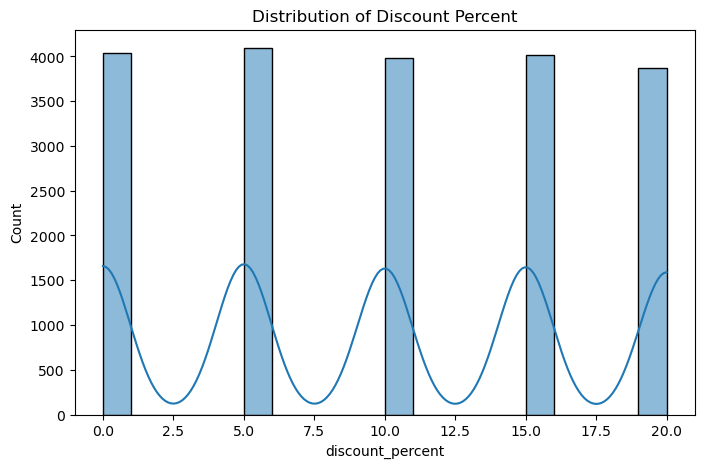

In [7]:
## Discount Percentage 
plt.figure(figsize=(8,5))
sns.histplot(product["discount_percent"], bins=20, kde=True)
plt.title("Distribution of Discount Percent")
plt.show()

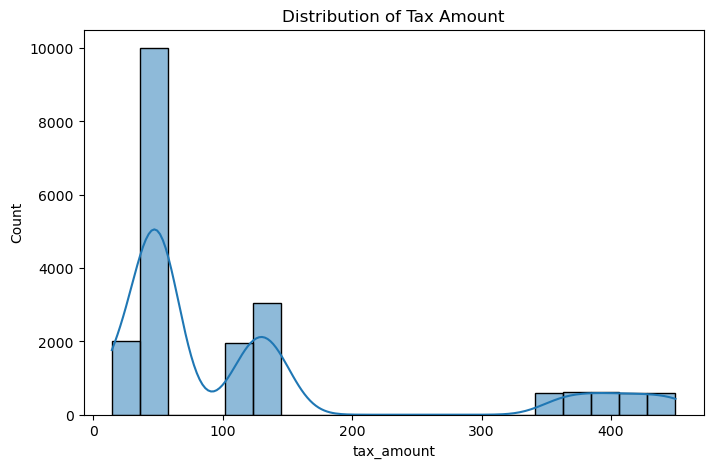

In [8]:
## Tax Amount 
plt.figure(figsize=(8,5))
sns.histplot(product["tax_amount"], bins=20, kde=True)
plt.title("Distribution of Tax Amount")
plt.show()

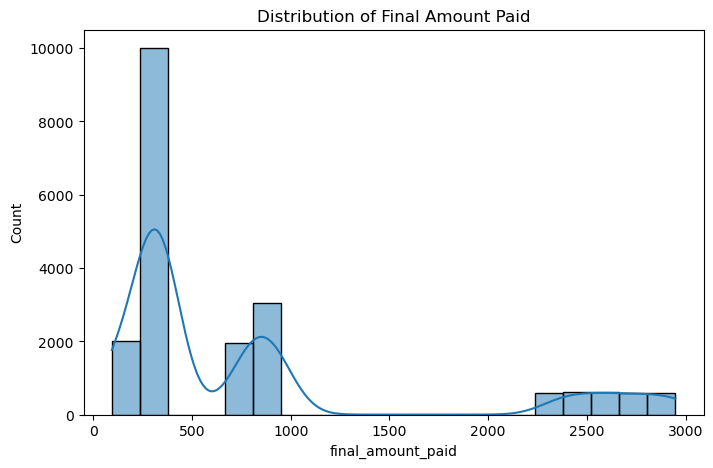

In [9]:
## Amount Paid 
plt.figure(figsize=(8,5))
sns.histplot(product["final_amount_paid"], bins=20, kde=True)
plt.title("Distribution of Final Amount Paid")
plt.show()

## Segment Analysis 

In [12]:
## plan category 
product.groupby("plan_category")[ ["discount_percent","tax_amount","final_amount_paid"]].agg(["mean","min","max"])

discount_percent          tax_amount                  \
                          mean min max        mean     min     max   
plan_category                                                        
Premium               9.875000   0  20  232.827812  115.06  449.82   
Standard              9.909167   0  20   43.088118   14.26   53.82   

              final_amount_paid                   
                           mean     min      max  
plan_category                                     
Premium             1526.304688  754.26  2948.82  
Standard             282.455543   93.46   352.82

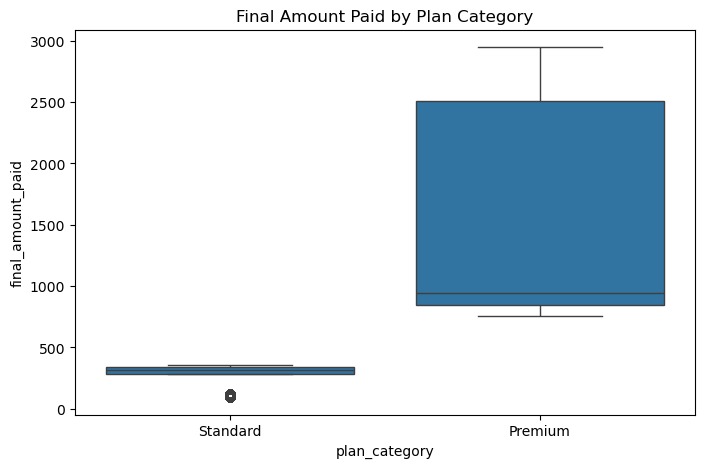

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="plan_category",
    y="final_amount_paid",
    data=product
)
plt.title("Final Amount Paid by Plan Category")
plt.show()

In [13]:
##payment status 
product.groupby("payment_status")[
    ["discount_percent","tax_amount","final_amount_paid"]
].agg(["mean","min","max"])

discount_percent          tax_amount                 \
                           mean min max        mean    min     max   
payment_status                                                       
Failed                 9.654762   0  20  123.047167  14.26  449.82   
Paid                   9.905282   0  20  118.746168  14.26  449.82   
Pending                9.849877   0  20  120.553854  14.26  449.82   

               final_amount_paid                  
                            mean    min      max  
payment_status                                    
Failed                806.631810  93.46  2948.82  
Paid                  778.436094  93.46  2948.82  
Pending               790.286544  93.46  2948.82

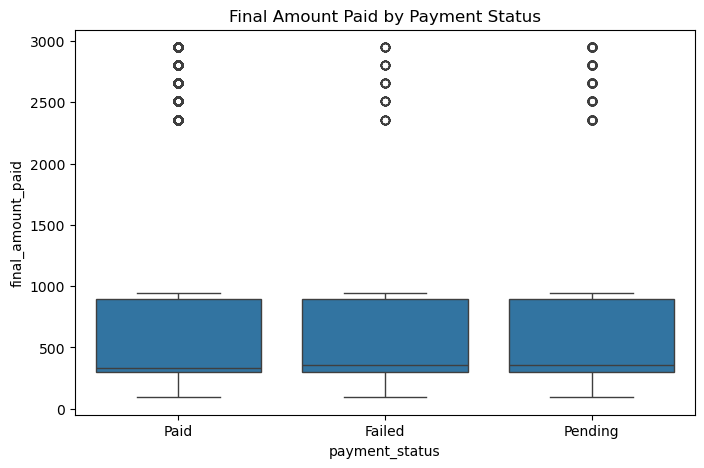

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="payment_status",
    y="final_amount_paid",
    data=product
)
plt.title("Final Amount Paid by Payment Status")
plt.show()

In [20]:
## subscription status
product.groupby("subscription_status")[
    ["discount_percent","tax_amount","final_amount_paid"]
].agg(["mean","min","max"])

discount_percent          tax_amount                 \
                                mean min max        mean    min     max   
subscription_status                                                       
Active                        9.8955   0  20  118.983996  14.26  449.82   

                    final_amount_paid                  
                                 mean    min      max  
subscription_status                                    
Active                     779.995201  93.46  2948.82

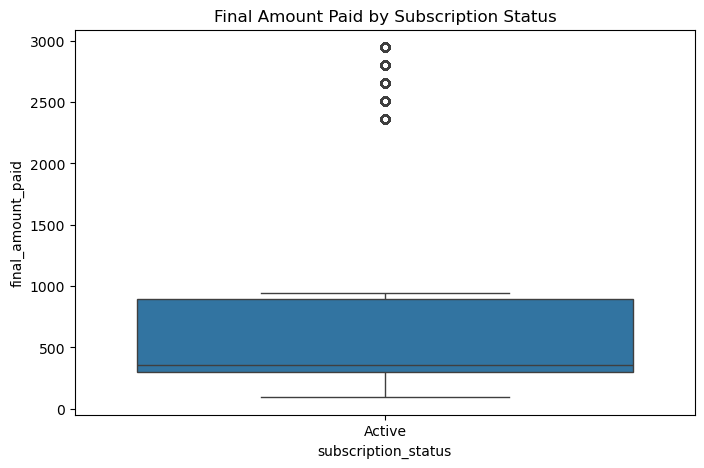

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="subscription_status",
    y="final_amount_paid",
    data=product
)
plt.title("Final Amount Paid by Subscription Status")
plt.show()

In [22]:
product["subscription_start_date"] = pd.to_datetime(product["subscription_start_date"])
product["subscription_end_date"] = pd.to_datetime(product["subscription_end_date"])

In [23]:
## Date Parts 
product["start_year"] = product["subscription_start_date"].dt.year
product["start_month"] = product["subscription_start_date"].dt.month
product["start_day"] = product["subscription_start_date"].dt.day
product["start_quarter"] = product["subscription_start_date"].dt.quarter
product["end_year"] = product["subscription_end_date"].dt.year
product["end_month"] = product["subscription_end_date"].dt.month
product["end_day"] = product["subscription_end_date"].dt.day
product["end_quarter"] = product["subscription_end_date"].dt.quarter

In [24]:
product[[
    "subscription_start_date",
    "start_year",
    "start_month",
    "start_day",
    "start_quarter",
    "subscription_end_date",
    "end_year",
    "end_month",
    "end_day",
    "end_quarter"
]].head()

,subscription_start_date,start_year,start_month,start_day,start_quarter,subscription_end_date,end_year,end_month,end_day,end_quarter
0,2023-05-18,2023,5,18,2,2023-06-17,2023,6,17,2
1,2024-03-04,2024,3,4,1,2024-04-03,2024,4,3,2
2,2023-10-28,2023,10,28,4,2023-11-27,2023,11,27,4
3,2023-02-12,2023,2,12,1,2023-05-13,2023,5,13,2
4,2024-02-15,2024,2,15,1,2025-02-14,2025,2,14,1


In [25]:
product.to_csv( r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv", index=False)